16 · Proximity graphs

When no relation between two entities is observed (no measured flow, no street
joining them) it can be postulated from geometric closeness. Choosing among
city2graph's seven constructions for points and one for polygons is not
neutral preprocessing: it is a hypothesis about which spatial relation is
analytically relevant.

- `knn_graph`: each point to its *k* nearest neighbors. The ranking matters,
  the absolute distance does not.
- `fixed_radius_graph`: everything inside a threshold, so the radius has
  physical meaning (a pedestrian catchment, a sensor's range).
- `delaunay_graph`, `gabriel_graph`, `relative_neighborhood_graph`,
  `euclidean_minimum_spanning_tree`: no *k* and no radius to choose, the
  structure comes out of the distribution itself.
- `waxman_graph`: probabilistic connection with exponential decay.
- `contiguity_graph`: for polygons, Queen or Rook adjacency.

`bridge_nodes` and `group_nodes` couple layers.

## 0 · Setup

In [1]:
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g
import geopandas as gpd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

ox = nb.osmnx()

CENTER = (39.4699, -0.3763)     # Ciutat Vella, València
RADIUS_M = 700
METRIC_CRS = "EPSG:25830"

## 1 · The points

Restaurants and cafés. Nodes only: POIs mapped as polygons would be reduced to
their centroid, mixing two different things.

In [2]:
pois = ox.features_from_point(
    CENTER, tags={"amenity": ["restaurant", "cafe", "bar"]}, dist=RADIUS_M)
pois = pois[pois.geometry.geom_type == "Point"]
pois = pois.to_crs(METRIC_CRS)[["amenity", "geometry"]].reset_index(drop=True)

print(f"{len(pois)} POIs")
print(pois["amenity"].value_counts().to_string())
check("enough points", len(pois) >= 20, f"{len(pois)}")

462 POIs
amenity
restaurant    301
cafe          115
bar            46
[PASS] enough points — 462


True

All of these functions need a projected CRS. In degrees,
`radius=100` is not 100 meters and the results mean nothing.

In [3]:
print("CRS:", pois.crs, "| geographic:", pois.crs.is_geographic)
check("metric CRS", not pois.crs.is_geographic)

CRS: EPSG:25830 | geographic: False
[PASS] metric CRS


True

## 2 · The seven constructions

The same point cloud, seven different hypotheses about what "near" means.

In [4]:
K = 5
RADIUS = 150.0     # meters

constructions = {
    "knn":       lambda g: c2g.knn_graph(g, k=K),
    "radius":    lambda g: c2g.fixed_radius_graph(g, radius=RADIUS),
    "delaunay":  lambda g: c2g.delaunay_graph(g),
    "gabriel":   lambda g: c2g.gabriel_graph(g),
    "rng":       lambda g: c2g.relative_neighborhood_graph(g),
    "emst":      lambda g: c2g.euclidean_minimum_spanning_tree(g),
    "waxman":    lambda g: c2g.waxman_graph(g, beta=0.5, r0=200.0, seed=42),
}

results = {}
print(f"{'construction':<12} {'nodes':>7} {'edges':>8} {'mean degree':>12} {'s':>6}")
print("-" * 50)
for name, func in constructions.items():
    t0 = time.time()
    nodes, edges = func(pois)
    results[name] = (nodes, edges)
    degree = 2 * len(edges) / len(nodes) if len(nodes) else 0
    print(f"{name:<12} {len(nodes):>7} {len(edges):>8} {degree:>12.2f} "
          f"{time.time() - t0:>6.2f}")

construction   nodes    edges  mean degree      s
--------------------------------------------------
knn              462     1418         6.14   0.02
radius           462     6495        28.12   0.06
delaunay         462     1364         5.90   0.02
gabriel          462      476         2.06   0.03
rng              462      550         2.38   0.04
emst             462      461         2.00   0.02
waxman           462     6979        30.21   0.23


The EMST is a tree: always `n-1` edges, the minimum needed to
keep everything connected. Delaunay is the densest of the non-parametric ones,
and in theory the four form a chain of subgraphs,
`EMST ⊆ RNG ⊆ Gabriel ⊆ Delaunay`, which is a free integrity test.

In [5]:
def edges_as_set(edges):
    return {tuple(sorted((a, b))) for a, b in edges.index}

edge_sets = {n: edges_as_set(e) for n, (_, e) in results.items()}

check("EMST is a tree",
      len(results["emst"][1]) == len(pois) - 1,
      f"{len(results['emst'][1])} edges for {len(pois)} nodes")
check("EMST ⊆ RNG", edge_sets["emst"] <= edge_sets["rng"])
check("Gabriel ⊆ Delaunay", edge_sets["gabriel"] <= edge_sets["delaunay"])

contained = edge_sets["rng"] <= edge_sets["gabriel"]
print(f"\nRNG ⊆ Gabriel: {contained}  "
      f"(|RNG| = {len(edge_sets['rng'])}, |Gabriel| = {len(edge_sets['gabriel'])}, "
      f"{len(edge_sets['rng'] - edge_sets['gabriel'])} RNG edges are not in Gabriel)")

[PASS] EMST is a tree — 461 edges for 462 nodes
[PASS] EMST ⊆ RNG
[PASS] Gabriel ⊆ Delaunay

RNG ⊆ Gabriel: False  (|RNG| = 550, |Gabriel| = 476, 416 RNG edges are not in Gabriel)


### A real bug in `gabriel_graph()`

`RNG ⊆ Gabriel` is a theorem, not a tendency: the RNG *lune*, the intersection
of two discs of radius `d(u,v)`, contains Gabriel's disc of diameter `uv`, so
the RNG condition is the stricter one. A failed containment means one of the
two implementations is wrong. It is `gabriel_graph()`, in
`city2graph/proximity.py:911`:

```python
tol = 1e-12
...
mask = d2 <= rad2 + tol
if np.count_nonzero(mask) == 2:
```

An absolute tolerance compared against squared distances. With UTM coordinates
(on the order of 4·10⁶ m), `d2` is around 10¹³ and `float64` leaves an absolute
error of ~10⁻³, nine orders of magnitude above the tolerance. Both endpoints
also sit *exactly* on the disc boundary, so `count == 2` depends on the noise.
False negatives and false positives at once, worse the larger the coordinates,
over 250 random points:

| Coordinates | `gabriel_graph()` | Correct |
|---|---|---|
| range 0 to 100 | 567 | 567 |
| range 0 to 1000 | 448 | 567 |
| real UTM 30N (725000, 4372000) | 248 | 453 |

A tolerance relative to `rad2` reproduces a brute-force check exactly.
`relative_neighborhood_graph`, `delaunay_graph` and
`euclidean_minimum_spanning_tree` are correct at any scale. Until it is fixed
upstream, use RNG instead of Gabriel, or translate the points to the origin
first: the result is translation invariant and that recovers much of the
precision.

In [6]:
# Translating to the origin is a palliative, not a fix.
pois_centered = pois.copy()
minx, miny, _, _ = pois.total_bounds
pois_centered["geometry"] = pois.geometry.translate(xoff=-minx, yoff=-miny)

_, gabriel_centered = c2g.gabriel_graph(pois_centered)
centered_set = edges_as_set(gabriel_centered)

print(f"Gabriel in UTM coordinates     : {len(edge_sets['gabriel'])} edges")
print(f"Gabriel translated to origin   : {len(centered_set)} edges")
check("translating to the origin restores the RNG ⊆ Gabriel containment",
      edge_sets["rng"] <= centered_set,
      f"{len(edge_sets['rng'] - centered_set)} RNG edges are still outside")

Gabriel in UTM coordinates     : 476 edges
Gabriel translated to origin   : 832 edges
[PASS] translating to the origin restores the RNG ⊆ Gabriel containment — 0 RNG edges are still outside


True

## 3 · The three into the viewport

Each graph in its own collection, offset along X: small multiples in three
dimensions.

In [7]:
sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(CENTER[0], CENTER[1], scale=0.001, name="Anchor_Proximity")

SEPARATION = 2.2
objects = {}
for i, (name, (nodes, edges)) in enumerate(results.items()):
    obj = sg.graphs.from_gdf(
        nodes, edges, name=f"Prox_{name}", ref=anchor,
        coll="C2G_Proximity",
        markers={"graph_type": name, "k": K, "radius_m": RADIUS})
    if obj is not None:
        obj.location.x += i * SEPARATION
        objects[name] = obj
        print(f"  {obj.name:<18} {obj.get('num_nodes'):>5} nodes, "
              f"{obj.get('num_edges'):>5} edges")

check("the seven graphs are in the scene", len(objects) == 7,
      f"{len(objects)}/7")

  Prox_knn             462 nodes,  1418 edges
  Prox_radius          462 nodes,  6495 edges
  Prox_delaunay        462 nodes,  1364 edges
  Prox_gabriel         462 nodes,   476 edges
  Prox_rng             462 nodes,   550 edges
  Prox_emst            462 nodes,   461 edges
  Prox_waxman          462 nodes,  6979 edges
[PASS] the seven graphs are in the scene — 7/7


True

Seven panels of the same point cloud, rendered with EEVEE as in
every notebook from 01 onwards. No ground under them: the seven are offset
along X and one terrain cannot sit under all of them; buildings arrive in
section 5. Straight down through an orthographic camera, `render_eevee`'s
default, with `look='ink'` and its turbo ramp on a near-black backdrop, shared
by notebooks 00 to 07 so their figures compare. The ramp carries `edge_weight`,
the distance in meters of the pair each construction connected.

Turbo is read by hue, not brightness. Over 256 steps its lightness correlates
with value at −0.02 against viridis's +1.00, falling as often as it rises (129
of 255 steps), leaving the order in blue → cyan → green → yellow → red. A tenth
of the range costs 19 to 71 units of CIE ΔE (viridis: 13 to 29), and the 0.2 to
0.3 band, holding a seventh of these edges, is stretched hardest.

Each panel is normalized to its own distribution: `render_eevee` takes
`vmin`/`vmax`, but the operator underneath re-derives the range from the
attribute's extremes, so an explicit range is silently discarded. Applied
afterwards, `clip_high_pct` does survive, and pulls in the top 2 % so a few
long links cannot flatten the rest into the bottom stop.

Blue therefore means "short *for this construction*", not "short in meters".
One absolute distance renders 114 ΔE apart at worst across the seven panels
under viridis, 128 under turbo; at 50 m, contained by all seven, 67 becomes
154. `waxman` gains: its 6,979 edges bunch at a third of its own range, close
to a single teal, and the share within ΔE 10 of the panel's median color drops
from 15.5 % to 4.9 %, the 0.2 to 0.4 stretch being where turbo spends most of
its color. Read the table: EMST and RNG have the lowest medians, `radius`
stops dead at the radius it was given, and `waxman` is the only one whose
maximum reaches the width of the cloud.

construction      min   median      p98       max  (meters)
----------------------------------------------------
knn                 1       45      173       304
radius              1       99      148       150
delaunay            1       52      223       531
gabriel             5       55      209       280
rng                 1       32      152       203
emst                1       28      117       176
waxman              1      233      786      1401

edge_weight domain: EDGE
knn: 1418 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 173.3] on Point


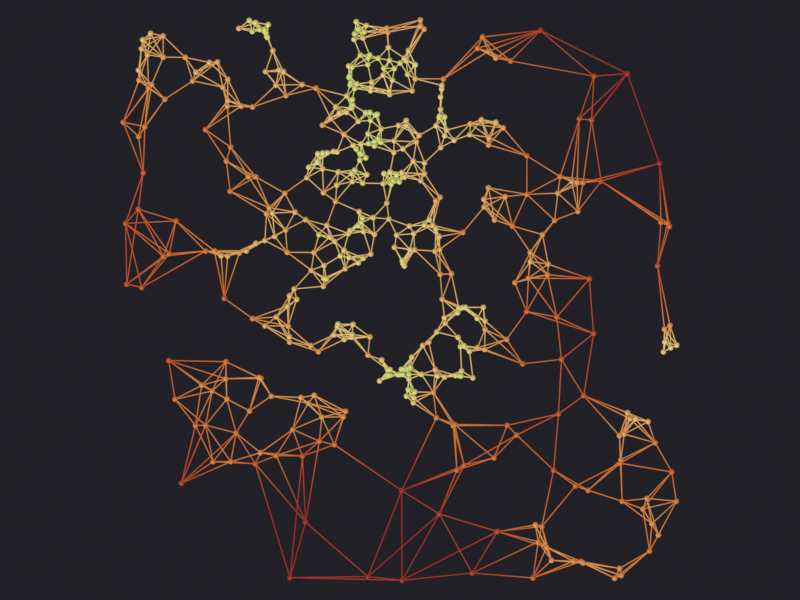

[PASS] 1_knn.png legible — 12.4% ink (healthy range 0.5–60%)
radius: 6495 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 148.3] on Point


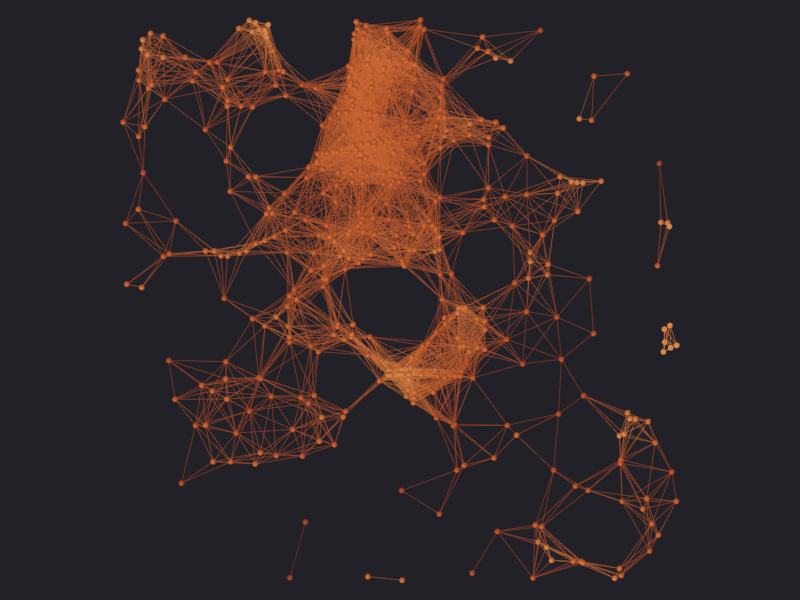

[PASS] 1_radius.png legible — 19.3% ink (healthy range 0.5–60%)
delaunay: 1364 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 222.6] on Point


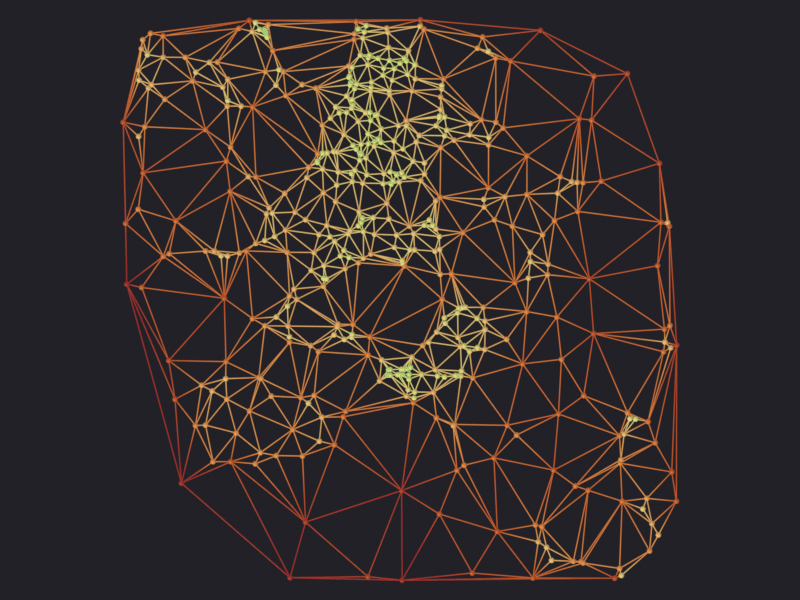

[PASS] 1_delaunay.png legible — 18.2% ink (healthy range 0.5–60%)
gabriel: 476 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [4.615 … 208.9] on Point


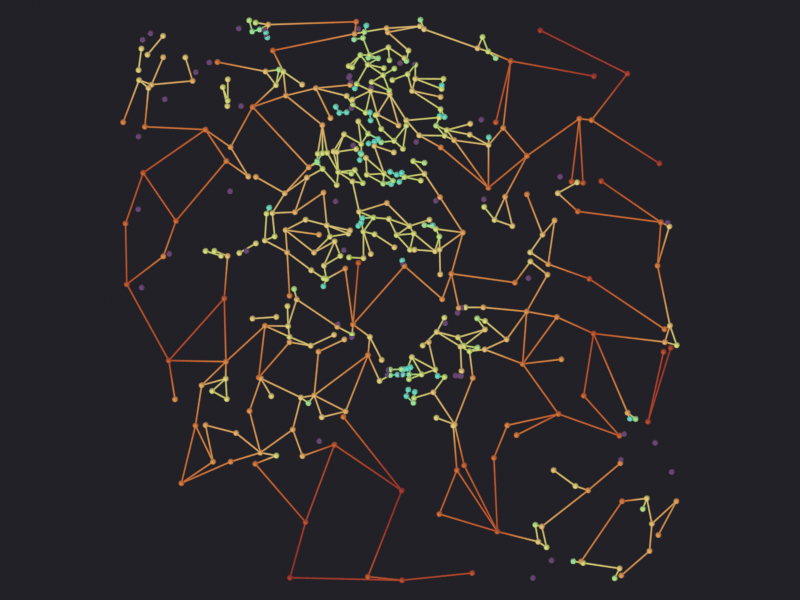

[PASS] 1_gabriel.png legible — 9.4% ink (healthy range 0.5–60%)
rng: 550 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 152.2] on Point


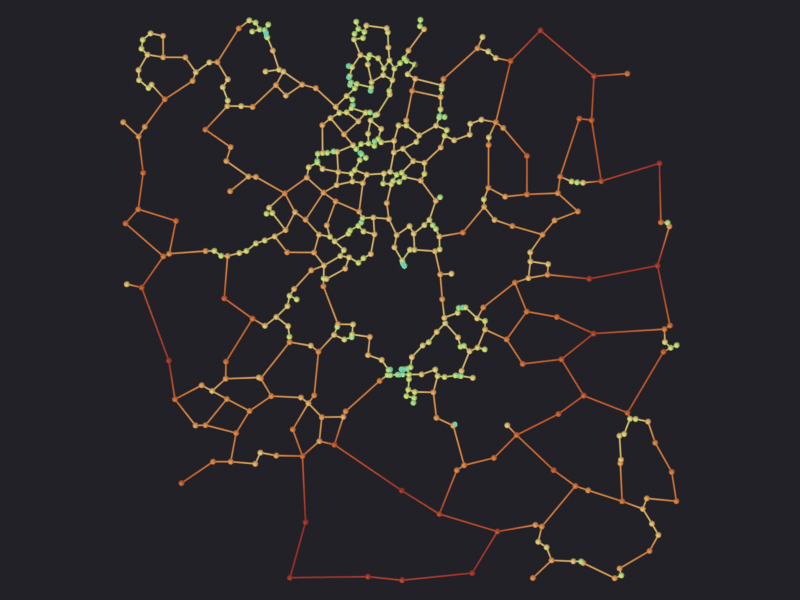

[PASS] 1_rng.png legible — 7.1% ink (healthy range 0.5–60%)
emst: 461 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 116.8] on Point


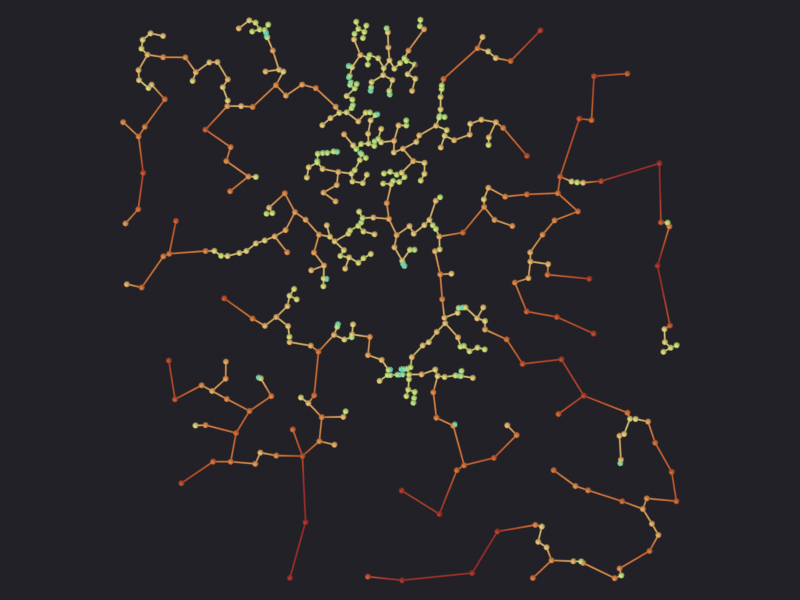

[PASS] 1_emst.png legible — 5.8% ink (healthy range 0.5–60%)
waxman: 6979 edges
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [1.474 … 786] on Point


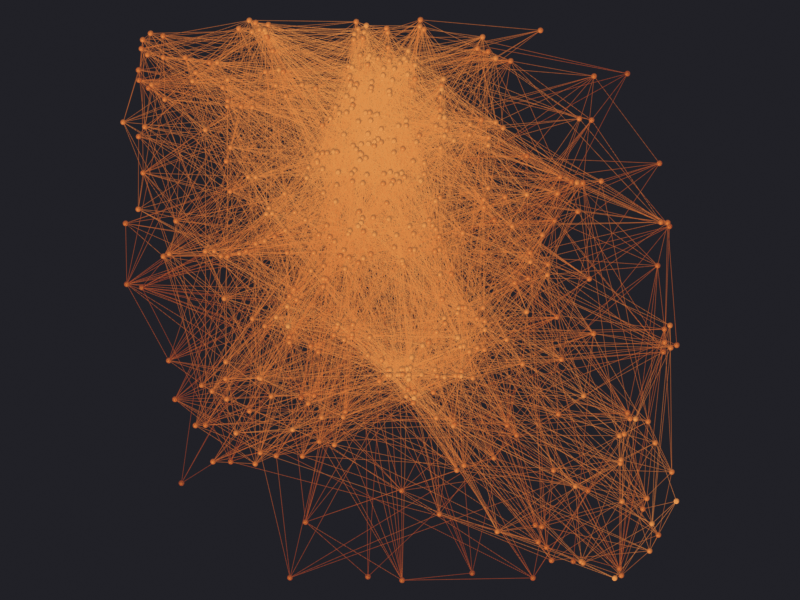

[PASS] 1_waxman.png legible — 43.5% ink (healthy range 0.5–60%)


In [8]:
print(f"{'construction':<12} {'min':>8} {'median':>8} {'p98':>8} {'max':>9}  (meters)")
print("-" * 52)
for name, (_nodes, edges) in results.items():
    if "weight" not in edges.columns:
        continue
    w = edges["weight"]
    print(f"{name:<12} {w.min():>8.0f} {w.median():>8.0f} "
          f"{w.quantile(0.98):>8.0f} {w.max():>9.0f}")

print("\nedge_weight domain:",
      sg.render.attribute_domain(next(iter(objects.values())), "edge_weight"))

for name, obj in objects.items():
    print(f"{name}: {len(results[name][1])} edges")
    nb.figure(obj, f"renders/02_proximity/1_{name}",
              resolution=(800, 600), width=700,
              look='ink', color_attribute="edge_weight",
              clip_high_pct=98)

In [9]:
for obj in objects.values():
    sg.graphs.visualize(obj, node_size=0.012, edge_thickness=0.002)
sg.graphs.frame()
print("Seven identical clouds, seven different topologies.")

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Seven identical clouds, seven different topologies.


## 4 · The distance metric is a hypothesis too

The same `fixed_radius_graph` and radius with Manhattan, Euclidean and network
distance give three different graphs. The network one measures along the
streets rather than as the crow flies, which is what matters when the threshold
stands for a walking time.

In [10]:
G_streets = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="walk", simplify=True)
_, streets_gdf = ox.graph_to_gdfs(G_streets)
streets_gdf = streets_gdf.to_crs(METRIC_CRS)

metrics = {}
for metric in ("euclidean", "manhattan"):
    nodes, edges = c2g.fixed_radius_graph(pois, radius=RADIUS, distance_metric=metric)
    metrics[metric] = (nodes, edges)

t0 = time.time()
nodes_net, edges_net = c2g.fixed_radius_graph(
    pois, radius=RADIUS, distance_metric="network", network_gdf=streets_gdf)
metrics["network"] = (nodes_net, edges_net)
print(f"network distance computed in {time.time() - t0:.1f} s "
      f"over {len(streets_gdf)} segments")

print()
for metric, (nodes, edges) in metrics.items():
    print(f"  {metric:<11} {len(edges):>6} edges within {RADIUS:.0f} m")

network distance computed in 2.6 s over 5534 segments

  euclidean     6495 edges within 150 m
  manhattan     4406 edges within 150 m
  network       4015 edges within 150 m


The network one always gives fewer or the same: walking the
street is never shorter than the straight line, and the difference measures how
much the urban fabric distorts real accessibility.

In [11]:
check("network ≤ euclidean",
      len(metrics["network"][1]) <= len(metrics["euclidean"][1]),
      f"{len(metrics['network'][1])} vs {len(metrics['euclidean'][1])}")

for i, (metric, (nodes, edges)) in enumerate(metrics.items()):
    obj = sg.graphs.from_gdf(
        nodes, edges, name=f"Radius_{metric}", ref=anchor,
        coll="C2G_Proximity_Metrics", markers={"distance_metric": metric})
    if obj is not None:
        obj.location.y -= 2.2
        obj.location.x += i * SEPARATION
        sg.graphs.visualize(obj, node_size=0.012, edge_thickness=0.002)

[PASS] network ≤ euclidean — 4015 vs 6495
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


## 5 · Polygons: `contiguity_graph()`

For areas the natural relation is not distance but sharing a border. City2Graph
wraps libpysal: Queen connects polygons sharing a border *or* a single vertex,
Rook requires a shared border. It is the usual homogeneous reference model for
asking what a purely spatial relation buys you, as notebook 18 does.

In [12]:
BLOCKS_RADIUS_M = 400

# Two shapes on purpose: section 5b needs `height` and `building:levels`, which
# only survive on the untrimmed download. From `blocks` alone a skyline could
# only be a constant.
blocks_osm = ox.features_from_point(CENTER, tags={"building": True},
                                    dist=BLOCKS_RADIUS_M)
blocks_osm = blocks_osm[blocks_osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
blocks = blocks_osm.to_crs(METRIC_CRS)[["geometry"]].reset_index(drop=True)
print(f"{len(blocks)} polygons")

nodes_q, edges_q = c2g.contiguity_graph(blocks, contiguity="queen")
nodes_r, edges_r = c2g.contiguity_graph(blocks, contiguity="rook")

print(f"queen {len(edges_q):>6} edges")
print(f"rook  {len(edges_r):>6} edges")
check("Queen contains Rook", len(edges_q) >= len(edges_r))

1022 polygons
queen   1270 edges
rook    1224 edges
[PASS] Queen contains Rook


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 190 disconnected components.
 There are 51 islands with ids: 50, 62, 63, 65, 69, 70, 74, 76, 77, 80, 90, 187, 216, 222, 223, 424, 431, 484, 491, 504, 577, 604, 622, 703, 721, 769, 788, 790, 791, 793, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 822, 829, 878, 895, 907, 908, 971, 1016.
  W.__init__(self, neighbors, ids=ids, **kw)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/libpysal/weights/contiguity.py:61: UserWarning: The weights matrix is not fully connected: 
 There are 193 disconnected components.
 There are 53 islands with ids: 50, 62, 63, 65, 69, 70, 74, 76, 77, 80, 90, 187, 216, 222, 223, 424, 431, 484, 490, 491, 504, 513, 577, 604, 622, 703, 721, 769, 788, 790, 791, 793, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 822, 829, 878, 895, 907, 908,

True

> The libpysal warning *"The weights matrix is not fully
> connected: there are N disconnected components"* is expected: a set of OSM
> buildings has blocks that touch no other one, and those are left as isolated
> components.

> **The equivalent operator is broken for contiguity.**
> `bpy.ops.scigraphs.generate_proximity_graph()` with
> `prox_graph_type = 'CONTIGUITY'` extracts the geometry with `as_points=True`,
> reducing every polygon to its representative point before calling
> `contiguity_graph()`. Two points never share a border, so it always returns
> zero edges and raises no error: libpysal only warns about "islands" in the
> console. Use the direct call in the previous cell. The operator's other seven
> constructions do pass the correct geometry.

{'object': 'Contiguity_Queen', 'type': 'MESH', 'num_nodes': 1022, 'num_edges': 1270, 'is_directed': False, 'vertices': 1022, 'mesh_edges': 1270, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_weight']}
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [2.323 … 40.22] on Point


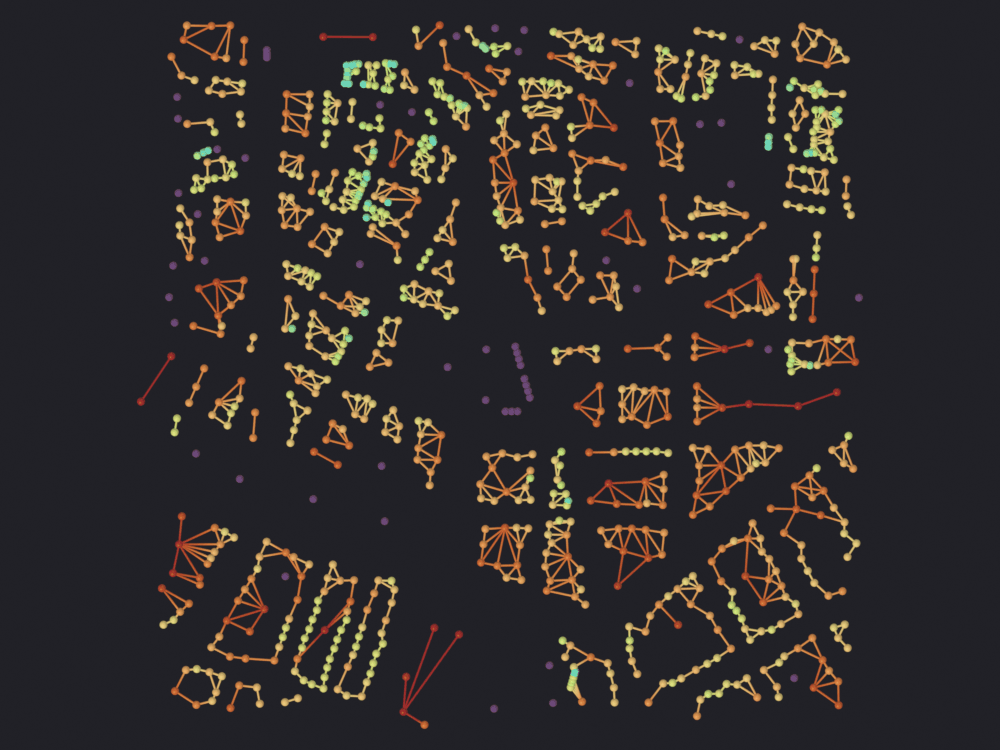

[PASS] 2_contiguity_queen.png legible — 12.9% ink (healthy range 0.5–60%)


In [13]:
obj_cont = sg.graphs.from_gdf(
    nodes_q, edges_q, name="Contiguity_Queen", ref=anchor,
    coll="C2G_Proximity_Polygons", markers={"contiguity": "queen"})
print(sg.graphs.summary(obj_cont))

# `contiguity_graph()` has no weight of its own but records the distance
# between the representative points it joined: a long edge crosses a large
# block, a short one is a party wall. The clip earns its place here. Distances
# run 2 m to 90 m, half between 13 and 23 m, and the 26 edges past the 98th
# percentile take the top 55 % of the ramp; clipped, the median moves from 0.17
# of the scale to 0.40.
nb.figure(obj_cont, "renders/02_proximity/2_contiguity_queen",
          look='ink', color_attribute="edge_weight",
          clip_high_pct=98)

### 5b · The same graph over the buildings it is made of

Every node above is a building footprint reduced to its representative point,
every edge two of them sharing a border or a corner. Over the extruded
footprints it becomes visibly a description of a block.

`add_context()` builds the ground and the prisms and drops the pair to street
level under the graph. It is handed `blocks_osm`, the tagged download rather
than the trimmed analysis copy, so prisms and nodes come from the same polygons.

The radius is padded by seventy percent, for two reasons.
`features_from_point(dist=400)` returns every footprint that *intersects* a
400 m box, so the polygons run past it and so do this graph's nodes: ground
built at exactly 400 m covers 91 % of it and the graph runs off its own ground.
That is what `check_alignment()` catches, and on a surface it is all it can
catch, since a terrain is symmetric about the anchor and so can only be too
small, never off-center; buildings carry absolute coordinates and can fail
either way. The rest is notebook 13's framing argument: an orthographic camera
framed tight on a square graph in a 4:3 frame needs ground about 1.4 times the
graph's own half-extent. A basemap in the wrong place is what
`check_alignment()` cannot catch, since draping an image moves no vertex; the
only test is below, whether the graph runs along the streets in the photograph.

- `terrain_source="flat"` reaches no network. Ciutat Vella has about twenty
  meters of relief across the frame, under two percent of it; notebook 17
  fetches a real DEM over this same center and reports what it got.
- `reference="all"`. By default `settle()` measures the ground, putting the
  graph at street level: right for notebook 17, where the nodes are
  intersections, wrong here. These nodes are the buildings' own representative
  points, so at street level each sits *inside* a twenty-meter prism and the
  render is a city with two or three white specks in it. `reference="all"`
  measures the tallest roof, so the context drops below the graph.
- `imagery="ESRI_IMAGERY"`. The claim of the figure is that the nodes *are*
  these roofs; on an aerial you can see the courtyards the footprints leave and
  check that edges cross party walls rather than streets. Zoom 17 costs 36
  tiles over a 1.2 km box, under a second cold and a quarter of that from disk,
  and this box is a little larger; the call prints the count it fetched. Each
  zoom step quarters or quadruples it, and the fetch refuses above 256 tiles.
  It also carries a license: the attribution line is printed below and belongs
  on anything published from this frame.

In [14]:
ctx = sg.context.add_context(obj_cont, CENTER, BLOCKS_RADIUS_M * 1.7, anchor,
                             buildings_gdf=blocks_osm,
                             terrain_source="flat", reference="all",
                             imagery="ESRI_IMAGERY", imagery_zoom=17)
print("real elevation:", ctx["real_elevation"])
print("real imagery  :", ctx["real_imagery"])
sg.context.report(ctx["objects"])

Creating terrain mesh: 2x2 vertices
Terrain mesh created: 4 vertices, 1 faces
  flat ground, 1360 x 1360 m (no elevation data)
  1022 footprints -> 12538 faces, 23032 vertices
  heights: 167 from OSM tags (16.3%), the rest at 21.0 m (median of tagged)
  Esri · Satellite (World Imagery): 6x6 = 36 tiles at zoom 17, 1536x1536 px
  36 already cached, 0 to fetch (~0.0 MB)
Basemap: ESRI_IMAGERY z=17 → 6×6=36 tiles (1536×1536 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z17_1787036061.png (1477×1477 px, 0/36 failed tiles)
scigraphs-utils available - Graphviz layouts enabled
  Esri · Satellite (World Imagery): 1477x1477 px in 0.3 s (36 tiles from cache)
  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community
  context moved -0.08600 Blender units (-86.0 m) so the tallest roof clears z=0 by 1 m
[PASS] Context_Ground aligned with Contiguity_Queen — center off by 0.0143 BU (1.16% of the graph diagonal), covers 100.0% of it, 1.55x its 

The credit line. `real_imagery` above is the only thing worth
trusting on whether the photograph arrived: a failed fetch puts the matte
material back and says so.

In [15]:
sg.context.attribution(ctx["objects"])

  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community


['Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community']

With `isolate=False` every mesh is rendered, and by now that is
the seven proximity graphs, the three distance-metric ones and this one, over a
grid of X and Y offsets. All but this one step out of the frame by hand.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_weight  ·  edge_weight -> turbo [log]  [2.323 … 40.22] on Point


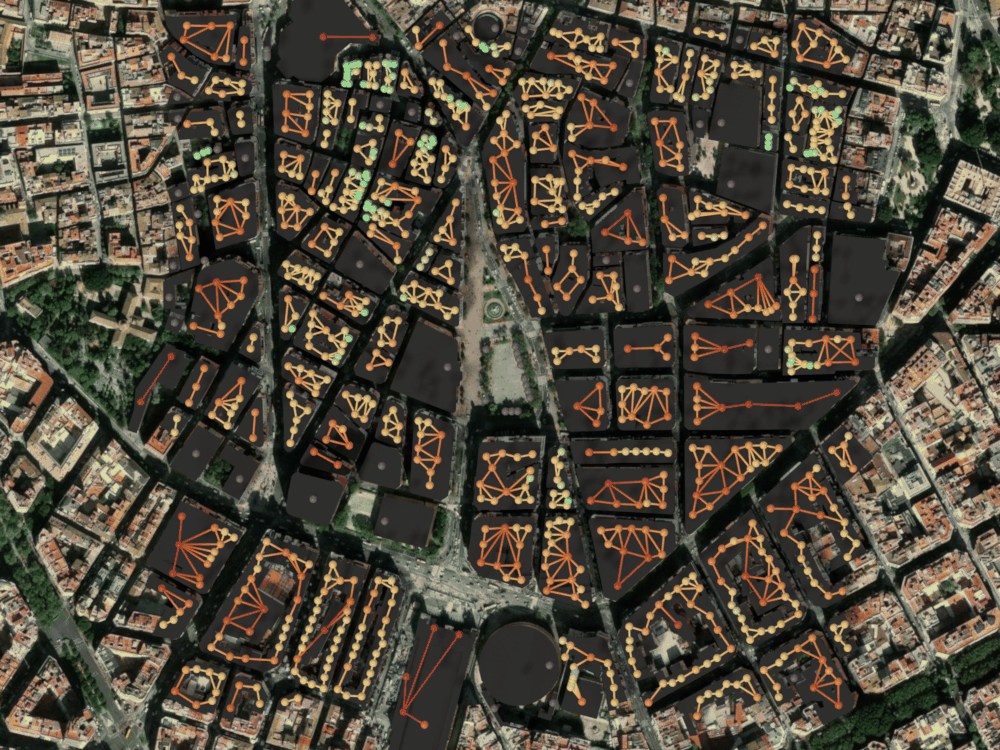

[PASS] 3_contiguity_over_buildings.png legible — 97.9% ink (healthy range 0.5–100%)


In [16]:
graphs = [o for o in bpy.data.objects
          if o.type == 'MESH' and "num_nodes" in o.keys()]
for obj in graphs:
    obj.hide_render = obj is not obj_cont

# Ink ceiling lifted for the usual overhead reason (notebook 13): against a
# full-frame aerial the corner pixel is a coin toss. The floor still applies.
path = nb.render(
    obj_cont, "renders/02_proximity/3_contiguity_over_buildings",
    isolate=False, look='ink', color_attribute="edge_weight",
    clip_high_pct=98, verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

for obj in graphs:
    obj.hide_render = False

The offset that lays this graph beside the others is applied
afterwards: the context was built about the anchor, and moving the graph away
first would leave the two 2.2 Blender units (2.2 km) apart.

In [17]:
if obj_cont is not None:
    obj_cont.location.y += 2.2
    sg.graphs.visualize(obj_cont, node_size=0.01, edge_thickness=0.002)

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


## 6 · Coupling layers: `bridge_nodes()`

It generates directed edges between semantic layers, extending kNN and fixed
radius across node types, and turns loose layers into a heterogeneous graph.
Here: restaurants, cafés and bars, with the `is_nearby` relations between them.

In [18]:
layers = {
    kind: pois[pois["amenity"] == kind][["geometry"]].reset_index(drop=True)
    for kind in ("restaurant", "cafe", "bar")
}
layers = {k: v for k, v in layers.items() if len(v) >= 3}
for name, gdf in layers.items():
    print(f"  {name:<12} {len(gdf):>4} points")

nodes_dict, edges_dict = c2g.bridge_nodes(layers, proximity_method="knn", k=3)
hetero_summary = nb.describe_hetero(nodes_dict, edges_dict)

  restaurant    301 points
  cafe          115 points
  bar            46 points
nodes
  restaurant                  301 Point
  cafe                        115 Point
  bar                          46 Point
edges
  restaurant -> is_nearby -> cafe                         903
  restaurant -> is_nearby -> bar                          903
  cafe -> is_nearby -> restaurant                         345
  cafe -> is_nearby -> bar                                345
  bar -> is_nearby -> restaurant                          138
  bar -> is_nearby -> cafe                                138


The keys of `edges_dict` are triplets
`(source_type, relation, target_type)`. That `(a, is_nearby, b)` and
`(b, is_nearby, a)` exist separately is not redundancy: the k nearest
neighbors are not a symmetric relation.

6 relation types
[PASS] the keys are triplets
[PASS] the relation is called is_nearby
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> layer_id  ·  layer_id -> turbo [log]  [0 … 2] on Point
{'object': 'Bridges_POI', 'type': 'MESH', 'num_nodes': 462, 'num_edges': 2236, 'is_directed': False, 'vertices': 462, 'mesh_edges': 2236, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'layer_id', 'node_id', 'edge_type_id', 'edge_weight', 'layer_id_color'], 'layer_names': 'restaurant,cafe,bar', 'edge_type_names': 'restaurant_is_nearby_cafe,restaurant_is_nearby_bar,cafe_is_nearby_restaurant,cafe_is_nearby_bar,bar_is_nearby_restaurant,bar_is_nearby_cafe', 'graph_type': 'bridge_nodes'}
layer_id domain: POINT
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> layer_id  ·  layer_id -> turbo [log]  [0 … 2] on Point


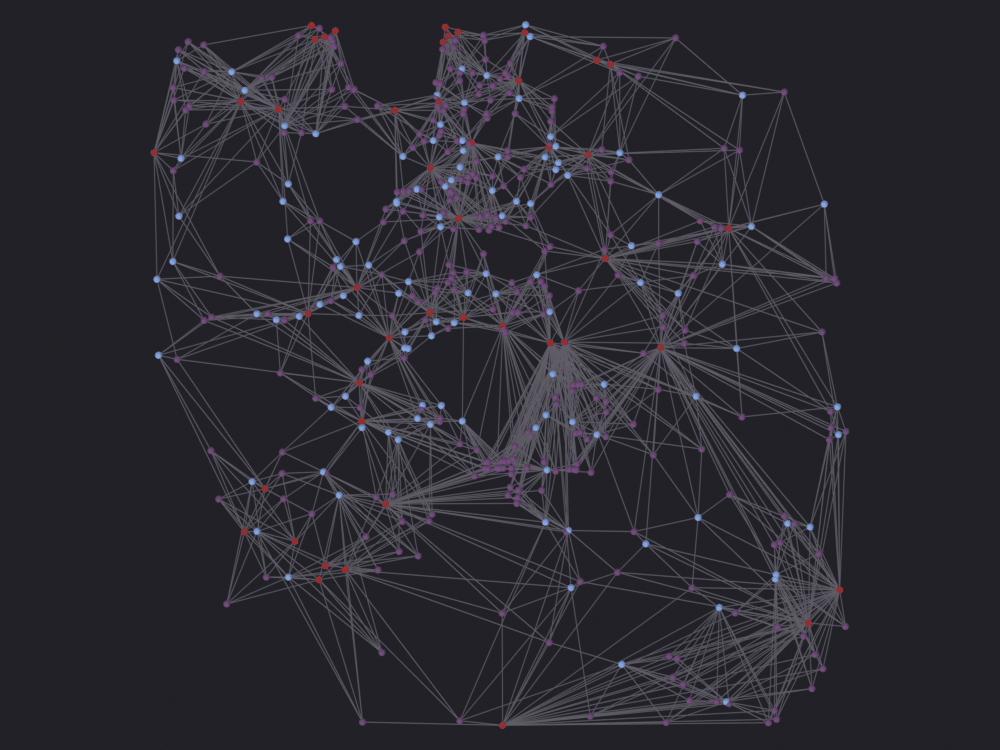

[PASS] 4_bridges_poi.png legible — 22.4% ink (healthy range 0.5–60%)


In [19]:
triplets = list(edges_dict.keys())
print(f"{len(triplets)} relation types")
check("the keys are triplets",
      all(isinstance(t, tuple) and len(t) == 3 for t in triplets))
check("the relation is called is_nearby",
      all(t[1] == "is_nearby" for t in triplets))

obj_bridge = sg.graphs.from_hetero(
    nodes_dict, edges_dict, name="Bridges_POI", ref=anchor,
    coll="C2G_Proximity_Multilayer",
    markers={"graph_type": "bridge_nodes"})
if obj_bridge is not None:
    obj_bridge.location.y += 4.4
    sg.graphs.visualize(obj_bridge, node_size=0.014, edge_thickness=0.002)
    sg.graphs.color_by(obj_bridge, "layer_id", colormap="turbo")
print(sg.graphs.summary(obj_bridge))
# Isolated because section 5b's buildings cover only the inner 400 m and this
# layer cake spans the full 700 m of the POI download.
#
# `layer_id` is a POINT attribute, so the ramp lands on the spheres and leaves
# the bridges neutral. Three categories need separable colors, not a perceptual
# order: turbo's closest pair is 61 ΔE apart, under viridis's 85 but far past
# where two categories merge.
print("layer_id domain:", sg.render.attribute_domain(obj_bridge, "layer_id"))
nb.figure(obj_bridge, "renders/02_proximity/4_bridges_poi",
          look='ink', color_attribute="layer_id")

## 7 · Hierarchy: `group_nodes()`

The other coupling strategy. Instead of connecting by closeness it nests points
inside the polygons that contain them: the membership relation (this stop is in
this neighborhood), which moves from the scale of the POI to the census unit.

In [20]:
zones = ox.features_from_point(CENTER, tags={"landuse": True}, dist=RADIUS_M)
zones = zones[zones.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
zones = zones.to_crs(METRIC_CRS)[["landuse", "geometry"]].reset_index(drop=True)
print(f"{len(zones)} land-use polygons")

if len(zones) >= 2:
    nodes_group, edges_group = c2g.group_nodes(
        zones, pois[["geometry"]], predicate="covered_by")
    nb.describe_hetero(nodes_group, edges_group)

    obj_group = sg.graphs.from_hetero(
        nodes_group, edges_group, name="Grouping_POI_Zone", ref=anchor,
        coll="C2G_Proximity_Groups", markers={"graph_type": "group_nodes"})
    if obj_group is not None:
        obj_group.location.y += 6.6
        sg.graphs.visualize(obj_group, node_size=0.014, edge_thickness=0.002)
    print(sg.graphs.summary(obj_group))
else:
    print("Not enough land-use polygons within this radius; "
          "try another center or a larger radius.")

235 land-use polygons
nodes
  polygon                     235 Polygon
  point                       462 Point
edges
  polygon -> covers -> point                              568
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
{'object': 'Grouping_POI_Zone', 'type': 'MESH', 'num_nodes': 697, 'num_edges': 568, 'is_directed': False, 'vertices': 697, 'mesh_edges': 568, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'layer_id', 'node_id', 'edge_type_id', 'edge_weight'], 'layer_names': 'polygon,point', 'edge_type_names': 'polygon_covers_point', 'graph_type': 'group_nodes'}


## 8 · The SciGraphs operator

For the seven point constructions the operator is faithful to city2graph. Load
the points as a features object, point `prox_feature_object` at it, and set the
type.

In [21]:
props = bpy.context.scene.city2graph

objs_poi = sg.graphs.from_features(pois, name="POIs_Valencia", ref=anchor,
                                   coll="C2G_Proximity_Operator")
if objs_poi:
    poi_obj = objs_poi[0]
    poi_obj["is_osm_features"] = True
    poi_obj["feature_count"] = len(pois)

    props.prox_feature_object = poi_obj
    props.prox_graph_type = 'KNN'
    props.prox_knn_k = K
    props.prox_distance_metric = 'EUCLIDEAN'
    props.prox_deduplicate = False       # keep the original indices and attributes

    result = bpy.ops.scigraphs.generate_proximity_graph()
    print("generate_proximity_graph ->", result)

    from_operator = [o for o in bpy.data.objects if o.get("is_proximity_graph")]
    for obj in from_operator:
        print(" ", sg.graphs.summary(obj))

    if from_operator:
        direct = len(results["knn"][1])
        via_op = from_operator[0].get("num_edges")
        check("the operator reproduces the direct kNN",
              abs(direct - via_op) <= max(2, direct * 0.02),
              f"direct {direct} vs operator {via_op}")

Using reference projection: center=(39.469900, -0.376300), scale=0.001
Created 1 object(s) from GeoDataFrame with 462 features
Generating KNN graph with metric=euclidean
  Deduplication: False, tolerance=0.5m
Loaded cached GeoDataFrame from object: 462 features (Point)
KNN graph created successfully in 0.04s
Info: Generating KNN proximity graph...
Info: Graph generated: 462 nodes, 1418 edges
Info: KNN graph created successfully (0.04s)
generate_proximity_graph -> {'FINISHED'}
  {'object': 'KNN_Graph', 'type': 'MESH', 'num_nodes': 462, 'num_edges': 1418, 'is_directed': False, 'vertices': 462, 'mesh_edges': 1418, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_weight'], 'graph_type': 'KNN'}
[PASS] the operator reproduces the direct kNN — direct 1418 vs operator 1418


> **About `prox_deduplicate`.** It is on by default and groups
> near-coincident points by rebuilding the GeoDataFrame as
> `GeoDataFrame(geometry=centroids, crs=...)`: all non-geometric columns are
> lost and the original index becomes a `RangeIndex`. To join the resulting
> graph back to the source data, turn it off, as the previous cell does.

## 9 · Saving

In [22]:
output_dir = nb.out("16_proximity")
output_dir.mkdir(parents=True, exist_ok=True)

for name, (nodes, edges) in results.items():
    sg.graphs.save_gdf(edges, output_dir / f"edges_{name}.gpkg")
sg.graphs.save_gdf(pois, output_dir / "pois.gpkg")

print("written to", nb.rel(output_dir))
print(f"  {len(list(output_dir.iterdir()))} files")

written to notebooks/out/16_proximity
  8 files


## Rendering

Every figure comes from EEVEE, through `nb.figure()`, drawn right
after the step that created each object; the PNGs are left in
`notebooks/out/renders/`. Notebook 13 explains how it works and why the
geographic notebooks put terrain and extruded buildings under their graphs.
Only the contiguity graph gets that treatment here.

> The Vulkan warning still applies, to the SciGraphs engine that notebooks 17
> and 06 keep for edge sparsification: on Blender's Vulkan backend (the default
> on Linux) `gpu.state.point_size_set` does nothing for the add-on shaders, so
> `POINT` and `DISK` nodes come out 1 pixel wide. Start Blender with
> `--gpu-backend opengl` for any render you intend to look at.

## Summary

| Spatial hypothesis | Function | Parameter |
|---|---|---|
| Relative proximity | `knn_graph` | `k` |
| Absolute proximity | `fixed_radius_graph` | `radius` |
| Natural neighborhood | `delaunay_graph`, `gabriel_graph`, `relative_neighborhood_graph` | none |
| Minimal connectivity | `euclidean_minimum_spanning_tree` | none |
| Decay with distance | `waxman_graph` | `beta`, `r0` |
| Shared border | `contiguity_graph` | `queen` / `rook` |
| Coupling between layers | `bridge_nodes` | `k` or `radius` |
| Hierarchical membership | `group_nodes` | `predicate` |

Next: **05 · Metapaths and the 15-minute city**.